In [2]:
import os
import random
from contextlib import nullcontext
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterator, List, Optional, Tuple

import clingo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
from skimage.color import rgb2gray
from skimage.measure import label, regionprops
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50
from torchvision.transforms import InterpolationMode

# 1.Model definiton

In [3]:
# Multi-task model skeleton with ResNet-50 backbone, dual heads, and stacked cross-fusion modules
class ConvBNReLU(nn.Module):
    """Utility block repeatedly used in decoder refinements (convolution + BN + ReLU)."""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, stride: int = 1):
        super().__init__()  # register parameters and buffers
        padding = kernel_size // 2  # preserve spatial size for odd kernels to keep skip connections aligned
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),  # stabilise feature statistics while training
            nn.ReLU(inplace=True),  # lightweight non-linearity reusing storage
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class ClassificationBranch(nn.Module):
    """Fully connected classifier with four hidden layers, dropout regularisation, and logits head."""

    def __init__(self, in_features: int, hidden_dims: Tuple[int, int, int, int], num_classes: int):
        super().__init__()
        if len(hidden_dims) != 4:
            raise ValueError("hidden_dims must contain four entries for the extended branch")
        self.hidden_dims = hidden_dims  # expose dims for cross-fusion wiring
        dims = (in_features,) + hidden_dims
        # Construct sequential linear layers that can be selectively invoked after each fusion stage
        self.layers = nn.ModuleList(
            nn.Linear(dims[i], dims[i + 1]) for i in range(len(hidden_dims))
        )
        self.dropout = nn.Dropout(p=0.3)  # regularise intermediate representations
        self.head = nn.Linear(hidden_dims[-1], num_classes)  # final logits for frame-level classification

    def activate_layer(self, x: torch.Tensor, idx: int) -> torch.Tensor:
        """Apply the idx-th hidden layer followed by ReLU and dropout."""
        if idx < 0 or idx >= len(self.layers):
            raise IndexError("Layer index out of range for classification branch")
        x = self.layers[idx](x)
        x = F.relu(x)
        return self.dropout(x)

    def final_logits(self, x: torch.Tensor) -> torch.Tensor:
        """Compute classification logits from the last hidden representation."""
        return self.head(x)


class SegmentationBranch(nn.Module):
    """Image-to-image decoder with additional refinement blocks for deeper fusion points."""

    def __init__(self, encoder_channels: Tuple[int, int, int, int, int], out_channels: int):
        super().__init__()
        c0, c1, c2, c3, c4 = encoder_channels
        # Standard U-Net style upsampling path: progressively merge encoder features with decoder activations
        self.reduce = ConvBNReLU(c4, 512, kernel_size=1)  # compress deepest features before upsampling
        self.up3 = ConvBNReLU(512 + c3, 256)
        self.up2 = ConvBNReLU(256 + c2, 128)
        self.up1 = ConvBNReLU(128 + c1, 96)
        self.up0 = ConvBNReLU(96 + c0, 64)
        # Refinement convolutions let fusion interactions happen on stable feature maps
        self.refine1 = ConvBNReLU(64, 64)  # refinement prior to second fusion
        self.refine2 = ConvBNReLU(64, 64)  # refinement prior to prediction
        # Produce background/lesion logits so a softmax classifier can score each pixel
        self.prediction = nn.Conv2d(64, out_channels, kernel_size=1)

    def decode(self, features: Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]) -> torch.Tensor:
        """Run the entire top-down decoder and return the high-resolution feature map for fusion."""
        c0, c1, c2, c3, c4 = features
        x = self.reduce(c4)
        x = F.interpolate(x, size=c3.shape[-2:], mode="bilinear", align_corners=False)
        x = self.up3(torch.cat([x, c3], dim=1))
        x = F.interpolate(x, size=c2.shape[-2:], mode="bilinear", align_corners=False)
        x = self.up2(torch.cat([x, c2], dim=1))
        x = F.interpolate(x, size=c1.shape[-2:], mode="bilinear", align_corners=False)
        x = self.up1(torch.cat([x, c1], dim=1))
        x = F.interpolate(x, size=c0.shape[-2:], mode="bilinear", align_corners=False)
        return self.up0(torch.cat([x, c0], dim=1))  # high-res feature map used for fusion

    def predict(self, features: torch.Tensor) -> torch.Tensor:
        """Project refined features to per-pixel logits (softmax later gives class probabilities)."""
        return self.prediction(features)


class CrossFusionModule(nn.Module):
    """Bidirectional cross-fusion: couples classification (global) and segmentation (dense) features."""

    def __init__(self, cls_channels: int, seg_channels: int):
        super().__init__()
        # Shared transformation matrix M from the paper (Eq. 7) implemented as a 1×1 convolution
        self.transform = nn.Conv2d(seg_channels, cls_channels, kernel_size=1, bias=False)
        self.pool = nn.AdaptiveAvgPool2d(1)  # used in the segmentation→classification path

    def forward(
        self,
        cls_feature: torch.Tensor,  # shape (batch, cls_channels, 1, 1)
        seg_feature: torch.Tensor,  # shape (batch, seg_channels, H, W)
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        # X'_cls = X_cls + Pool(M(X_seg)) — Eq. (7a) converts dense activations to a global descriptor
        seg_to_cls = self.pool(self.transform(seg_feature))
        fused_cls = cls_feature + seg_to_cls

        # X'_seg = X_seg + M^T(Pad(X_cls)) — Eq. (7b) injects classification context into the decoder
        h, w = seg_feature.shape[-2:]
        cls_expanded = cls_feature.expand(-1, cls_feature.size(1), h, w)  # Pad(X_cls) for spatial compatibility
        cls_to_seg = F.conv_transpose2d(cls_expanded, self.transform.weight)  # transpose convolution applies M^T
        fused_seg = seg_feature + cls_to_seg
        return fused_cls, fused_seg


class MultiTask(nn.Module):
    """Multi-task architecture with shared ResNet-50 encoder and stacked cross-fusion heads."""

    def __init__(
        self,
        num_classes: int,
        num_segmentation_classes: int = 2,
        trainable_backbone_layers: int = 3,
        use_pretrained: bool = True,
        classification_hidden_dims: Tuple[int, int, int, int] = (1024, 512, 256, 128),
    ):
        super().__init__()
        weights = ResNet50_Weights.DEFAULT if use_pretrained else None
        backbone = resnet50(weights=weights)

        # Expose ResNet-50 feature stages for skip connections and fine-tuning control
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        self.pool0 = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self._set_trainable_layers(trainable_backbone_layers)

        encoder_channels = (64, 256, 512, 1024, 2048)  # channel counts produced by each ResNet stage
        self.classification_hidden_dims = classification_hidden_dims
        self.classifier_pool = nn.AdaptiveAvgPool2d(1)  # compress encoder output before the MLP
        self.classifier_branch = ClassificationBranch(
            in_features=encoder_channels[-1], hidden_dims=classification_hidden_dims, num_classes=num_classes
        )
        self.segmentation_branch = SegmentationBranch(
            encoder_channels=encoder_channels, out_channels=num_segmentation_classes
        )

        # Two cross-fusion modules placed between consecutive layers of each branch per revised spec
        self.cross_fusion_primary = CrossFusionModule(
            cls_channels=self.classifier_branch.hidden_dims[0], seg_channels=64
        )
        self.cross_fusion_secondary = CrossFusionModule(
            cls_channels=self.classifier_branch.hidden_dims[2], seg_channels=64
        )

    def _set_trainable_layers(self, trainable_backbone_layers: int) -> None:
        """Freeze early ResNet blocks to control how much of the backbone is fine-tuned."""
        stages = [
            self.stem,
            self.pool0,
            self.layer1,
            self.layer2,
            self.layer3,
            self.layer4,
        ]
        if trainable_backbone_layers < 1 or trainable_backbone_layers > len(stages):
            raise ValueError(
                f"trainable_backbone_layers must be between 1 and {len(stages)}; got {trainable_backbone_layers}"
            )
        trainable_modules = set(stages[-trainable_backbone_layers:])
        for module in stages:
            for param in module.parameters():
                param.requires_grad = module in trainable_modules

    def forward(
        self,
        x: torch.Tensor,
        task: Optional[str] = None,
    ) -> Dict[str, torch.Tensor]:
        """Run shared encoder, two-stage cross-fusion, and emit requested task predictions."""
        if task and task not in {"classification", "segmentation"}:
            raise ValueError("task must be 'classification', 'segmentation', or None")

        # Shared ResNet-50 encoder produces multi-scale features for both tasks
        c0 = self.stem(x)
        p0 = self.pool0(c0)
        c1 = self.layer1(p0)
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)
        encoder_features = (c0, c1, c2, c3, c4)

        # First branch layers
        seg_stage0 = self.segmentation_branch.decode(encoder_features)  # segmentation layer 1
        cls_vector0 = self.classifier_pool(c4).flatten(1)  # base embedding for the classifier
        cls_hidden1 = self.classifier_branch.activate_layer(cls_vector0, idx=0)  # classification layer 1
        cls_hidden1_map = cls_hidden1.view(cls_hidden1.size(0), cls_hidden1.size(1), 1, 1)

        fusion_penalties: List[torch.Tensor] = []

        # Cross-fusion between first and second layers
        cls_fused1, seg_fused1 = self.cross_fusion_primary(cls_hidden1_map, seg_stage0)
        fusion_penalties.append(F.mse_loss(cls_fused1, cls_hidden1_map, reduction="mean"))
        fusion_penalties.append(F.mse_loss(seg_fused1, seg_stage0, reduction="mean"))

        cls_stage1 = cls_fused1.flatten(1)
        cls_hidden2 = self.classifier_branch.activate_layer(cls_stage1, idx=1)  # classification layer 2
        seg_stage1 = self.segmentation_branch.refine1(seg_fused1)  # segmentation layer 2

        # Progress to third layers of both branches
        cls_hidden3 = self.classifier_branch.activate_layer(cls_hidden2, idx=2)  # classification layer 3
        cls_hidden3_map = cls_hidden3.view(cls_hidden3.size(0), cls_hidden3.size(1), 1, 1)
        seg_stage2 = self.segmentation_branch.refine2(seg_stage1)  # segmentation layer 3

        # Cross-fusion between third and final layers
        cls_fused2, seg_fused2 = self.cross_fusion_secondary(cls_hidden3_map, seg_stage2)
        fusion_penalties.append(F.mse_loss(cls_fused2, cls_hidden3_map, reduction="mean"))
        fusion_penalties.append(F.mse_loss(seg_fused2, seg_stage2, reduction="mean"))

        cls_stage3 = cls_fused2.flatten(1)
        cls_hidden4 = self.classifier_branch.activate_layer(cls_stage3, idx=3)  # classification layer 4
        cls_logits = self.classifier_branch.final_logits(cls_hidden4)

        seg_logits = self.segmentation_branch.predict(seg_fused2)  # segmentation final layer
        seg_logits = F.interpolate(seg_logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

        fusion_reg = torch.stack(fusion_penalties).sum()

        outputs: Dict[str, torch.Tensor] = {}
        requested = {task} if task else {"classification", "segmentation"}
        if "classification" in requested:
            outputs["classification"] = cls_logits
            outputs["fusion_reg"] = fusion_reg
        if "segmentation" in requested:
            outputs["segmentation"] = seg_logits
        return outputs


# 2.Symbolic analyzer

In [4]:
class SkinLesionAnalyzer:
    def extract_features(self, image_tensor, mask_tensor):
        """
        Converts PyTorch tensors into numerical ABCD features.
        """
        # Convert tensors to numpy
        # Image: [C, H, W] -> [H, W, C]
        image_np = image_tensor.permute(1, 2, 0).cpu().numpy()

        # Mask: ensure 2D [H, W]
        mask_np = mask_tensor.detach().cpu().numpy()
        if mask_np.ndim == 3:
            # If mask has channel dimension, pick lesion channel when possible
            if mask_np.shape[0] > 1:
                mask_np = mask_np[1]
            else:
                mask_np = mask_np[0]
        elif mask_np.ndim == 4:
            # If batch dimension slipped in, squeeze it out
            mask_np = mask_np[0, 0]
        mask_np = (mask_np > 0.5).astype(int)

        if np.sum(mask_np) == 0:
            return None  # No lesion detected

        props = regionprops(label(mask_np))[0]

        # --- Asymmetry ---
        flip_lr = np.fliplr(mask_np)
        flip_ud = np.flipud(mask_np)
        iou_lr = np.sum(mask_np & flip_lr) / np.sum(mask_np | flip_lr)
        iou_ud = np.sum(mask_np & flip_ud) / np.sum(mask_np | flip_ud)
        asymmetry_index = 1.0 - ((iou_lr + iou_ud) / 2.0)

        # --- Border ---
        compactness = (props.perimeter ** 2) / (4 * np.pi * props.area)

        # --- Color ---
        # Mask the original image to get lesion pixels
        masked_pixels = rgb2gray(image_np)[mask_np == 1]
        color_std = np.std(masked_pixels) if masked_pixels.size > 0 else 0

        # --- Diameter ---
        diameter = props.equivalent_diameter

        return {
            "asymmetry": asymmetry_index,
            "border": compactness,
            "color": color_std,
            "diameter": diameter
        }, mask_np

    def features_to_facts(self, feats):
        facts = []
        # Tuning these thresholds is part of the "Adaptation" phase
        if feats["asymmetry"] > 0.15: facts.append("feature(asymmetry, high).")
        else: facts.append("feature(asymmetry, low).")
            
        if feats["border"] > 1.8: facts.append("feature(border, irregular).")
        else: facts.append("feature(border, regular).")
            
        if feats["color"] > 0.15: facts.append("feature(color, variegated).")
        else: facts.append("feature(color, uniform).")
            
        if feats["diameter"] > 80: facts.append("feature(diameter, large).")
        else: facts.append("feature(diameter, small).")
            
        return facts

# 3. ASP Reasoning Engine

In [5]:
ASP_PROGRAM = """
% --- Knowledge Base ---
% Weighted risk contributions with finer-grained feature levels.
% Asymmetry
risk_score(asymmetry, 6)  :- feature(asymmetry, medium).
risk_score(asymmetry, 10) :- feature(asymmetry, high).
% Border
risk_score(border, 6)     :- feature(border, slightly_irregular).
risk_score(border, 10)    :- feature(border, irregular).
% Color
risk_score(color, 5)      :- feature(color, variegated).
risk_score(color, 8)      :- feature(color, highly_variegated).
% Diameter
risk_score(diameter, 3)   :- feature(diameter, medium).
risk_score(diameter, 5)   :- feature(diameter, large).

% Evidence aggregation
total_risk(S) :- S = #sum { P,F : risk_score(F,P) }.
feature_count(N) :- N = #count { F,V : feature(F,V) }.
weighted_avg10(R10) :- total_risk(S), feature_count(N), N > 0, R10 = (S * 10) / N.

% Logic-based Diagnosis (scaled thresholds to avoid floats)
logic_pred(melanoma) :- total_risk(S), S >= 18.
logic_pred(melanoma) :- total_risk(S), S >= 14, weighted_avg10(R10), R10 >= 40.
logic_pred(benign)   :- total_risk(S), S < 12.
logic_pred(benign)   :- total_risk(S), S < 14, weighted_avg10(R10), R10 < 35.
logic_pred(uncertain) :- not logic_pred(melanoma), not logic_pred(benign).

% --- Explanation Generation ---
% Positive Evidence
explanation("High asymmetry suggests unorganized growth.") :- feature(asymmetry, high).
explanation("Moderate asymmetry suggests mild structural imbalance.") :- feature(asymmetry, medium).
explanation("Irregular borders indicate invasive growth patterns.") :- feature(border, irregular).
explanation("Slight border irregularity can indicate early changes.") :- feature(border, slightly_irregular).
explanation("Color variation suggests pigment heterogeneity.") :- feature(color, variegated).
explanation("Strong color variegation suggests deep pigmentary changes.") :- feature(color, highly_variegated).
explanation("Large diameter increases lesion risk.") :- feature(diameter, large).
explanation("Moderate diameter may warrant monitoring.") :- feature(diameter, medium).

% Negative Evidence
explanation("Low asymmetry supports benign appearance.") :- feature(asymmetry, low).
explanation("Regular borders support benign appearance.") :- feature(border, regular).
explanation("Uniform color supports benign appearance.") :- feature(color, uniform).
explanation("Small diameter supports benign appearance.") :- feature(diameter, small).

% 2. Consistency Validation
consistency("AGREEMENT: Visual evidence supports the AI diagnosis.") :- 
    nn_pred(C), logic_pred(C).
consistency("CONFLICT: Visual features contradict the AI diagnosis.") :- 
    nn_pred(C1), logic_pred(C2), C1 != C2.
consistency("UNCERTAIN: Visual evidence is borderline.") :- logic_pred(uncertain).

% Output Interface
#show explanation/1.
#show consistency/1.
#show total_risk/1.
#show weighted_avg10/1.
#show logic_pred/1.
"""

def explain_prediction(facts, nn_class):
    ctl = clingo.Control()
    ctl.add("base", [], ASP_PROGRAM)
    ctl.add("base", [], f"nn_pred({nn_class}). " + " ".join(facts))
    ctl.ground([("base", [])])
    
    response = {"explanations": [], "consistency": [], "risk": 0, "logic_pred": ""}
    
    def on_model(m):
        for atom in m.symbols(shown=True):
            if atom.name == "explanation":
                response["explanations"].append(str(atom.arguments[0]).strip('"'))
            elif atom.name == "consistency":
                response["consistency"].append(str(atom.arguments[0]).strip('"'))
            elif atom.name == "total_risk":
                response["risk"] = atom.arguments[0].number
            elif atom.name == "logic_pred":
                response["logic_pred"] = str(atom.arguments[0])

    ctl.solve(on_model=on_model)
    return response

# 4.Main workflow

In [18]:
# A. Setup
device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
 )
print(f"Using device: {device}")

# B. Load Model
model_path = "/Users/enricotazzer/Desktop/multi-task-learning-for-classification-and-segmentation-of-skin-lesions/trained_models/multitask_fl.pth"

checkpoint = torch.load(model_path, map_location=device, weights_only=False)
if isinstance(checkpoint, dict) and not isinstance(checkpoint, nn.Module):
    # Handle training checkpoints with a "model" key
    state_dict = checkpoint.get("model")
    if state_dict is None:
        # Fallback to direct state_dict or nested "state_dict"
        state_dict = checkpoint.get("state_dict", checkpoint)
    # Infer head sizes from weights when possible (support nested prefixes like "module.")
    def _find_key_ending(suffix: str) -> Optional[str]:
        for key in state_dict.keys():
            if key.endswith(suffix):
                return key
        return None

    def _infer_hidden_dims() -> Optional[Tuple[int, int, int, int]]:
        dims: List[int] = []
        for idx in range(4):
            key = _find_key_ending(f"classifier_branch.layers.{idx}.weight")
            if key is None:
                return None
            dims.append(state_dict[key].shape[0])
        return tuple(dims)  # type: ignore[return-value]

    cls_key = _find_key_ending("classifier_branch.head.weight")
    seg_key = _find_key_ending("segmentation_branch.prediction.weight")
    if cls_key is None or seg_key is None:
        available = list(state_dict.keys())[:20]
        raise ValueError(
            "Checkpoint does not contain expected classifier/segmentation head weights. "
            f"Examples of keys: {available}"
)
    num_classes = state_dict[cls_key].shape[0]
    num_segmentation_classes = state_dict[seg_key].shape[0]
    inferred_hidden_dims = _infer_hidden_dims()
    model_kwargs = dict(checkpoint.get("model_kwargs", {}))
    model_kwargs.setdefault("num_classes", num_classes)
    model_kwargs.setdefault("num_segmentation_classes", num_segmentation_classes)
    model_kwargs.setdefault("trainable_backbone_layers", 3)
    model_kwargs.setdefault("use_pretrained", False)
    if "classification_hidden_dims" not in model_kwargs:
        model_kwargs["classification_hidden_dims"] = inferred_hidden_dims or (1024, 512, 256, 128)
    model = MultiTask(**model_kwargs)

    # Load only compatible tensors to avoid size-mismatch errors
    model_state = model.state_dict()
    incompatible: List[str] = []
    for key, tensor in state_dict.items():
        if key in model_state and model_state[key].shape == tensor.shape:
            model_state[key] = tensor
        else:
            incompatible.append(key)
    missing, unexpected = model.load_state_dict(model_state, strict=False)
    if incompatible:
        print(f"Skipping incompatible weights ({len(incompatible)}). Example: {incompatible[:3]}")
    if missing:
        print(f"Missing keys after load: {missing[:5]}")
    if unexpected:
        print(f"Unexpected keys after load: {unexpected[:5]}")
else:
    # Full model object saved via torch.save(model)
    model = checkpoint

model.to(device)
model.eval()
print("Model loaded successfully.")

# C. Load Dataset Manifest and Select Random Images
dataset_root = Path("/Volumes/T7/largeProject_copy/multitask_fully_labeled")
manifest_path = dataset_root / "manifest.csv"

if not manifest_path.exists():
    raise FileNotFoundError(f"Manifest not found: {manifest_path}")

# Load manifest
df = pd.read_csv(manifest_path)

# Define benign and malignant classes
# MEL=Melanoma, BCC=Basal Cell Carcinoma, AKIEC=Actinic Keratoses
benign_classes = ["NV", "BKL", "DF"]  # Nevus, Benign Keratosis, Dermatofibroma
malignant_classes = ["MEL", "BCC", "AKIEC", "VASC"]  # Melanoma, BCC, AKIEC, Vascular

# Filter for benign and malignant samples
benign_df = df[df[benign_classes].sum(axis=1) > 0]
malignant_df = df[df[malignant_classes].sum(axis=1) > 0]

if len(benign_df) == 0:
    raise RuntimeError("No benign samples found in manifest")
if len(malignant_df) == 0:
    raise RuntimeError("No malignant samples found in manifest")

# Randomly select one from each category
benign_sample = benign_df.sample(n=1).iloc[0]
malignant_sample = malignant_df.sample(n=1).iloc[0]

selected_samples = [
    ("BENIGN", benign_sample),
    ("MALIGNANT", malignant_sample)
]

print(f"\nSelected samples:")
print(f"  Benign:    {benign_sample['image_id']}")
print(f"  Malignant: {malignant_sample['image_id']}")

# D. Data Preparation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# E-F. Process Both Images
analyzer = SkinLesionAnalyzer()

for sample_type, sample_row in selected_samples:
    image_path = dataset_root / sample_row["image"]
    
    if not image_path.exists():
        print(f"Warning: Image not found: {image_path}")
        continue
    
    # Get ground truth label
    class_names = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
    label_vector = sample_row[class_names].values
    gt_class_idx = int(label_vector.argmax())
    gt_class_name = class_names[gt_class_idx]
    
    # Load and Preprocess
    img_pil = Image.open(image_path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    # Inference
    with torch.no_grad():
        outputs = model(img_tensor)
        
        # Process Classification Output
        class_logits = outputs["classification"] if isinstance(outputs, dict) else outputs[0]
        probs = torch.softmax(class_logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_class_name = class_names[pred_idx]
        
        # Malignant classes: MEL (0), BCC (2), AKIEC (3), VASC (6)
        melanoma_classes = [0, 2, 3, 6]
        nn_class = "melanoma" if pred_idx in melanoma_classes else "benign"
        confidence = probs[0][pred_idx].item()
        
        # Process Segmentation Output
        seg_logits = outputs["segmentation"] if isinstance(outputs, dict) else outputs[1]
        mask_prob = torch.sigmoid(seg_logits)
    
    # Explainability Pipeline
    features, mask_np = analyzer.extract_features(img_tensor[0], mask_prob[0])
    
    if features is None:
        print(f"\nWarning: No lesion detected in {sample_type} image")
        continue
    
    facts = analyzer.features_to_facts(features)
    explanation = explain_prediction(facts, nn_class)
    
    # Report Generation
    print("\n" + "=" * 80)
    print(f" DIAGNOSTIC REPORT - {sample_type} SAMPLE")
    print("=" * 80)
    print(f"Image ID:           {sample_row['image_id']}")
    print(f"Ground Truth:       {gt_class_name}")
    print(f"AI Prediction:      {pred_class_name} ({nn_class.upper()}) (Confidence: {confidence:.2%})")
    print(f"Logic Audit:        {explanation['logic_pred'].upper()}")
    print(f"Risk Score:         {explanation['risk']} / 40")
    print("-" * 80)
    print("EXTRACTED FEATURES:")
    print(f"  Asymmetry:  {features['asymmetry']:.3f}")
    print(f"  Border:     {features['border']:.3f}")
    print(f"  Color:      {features['color']:.3f}")
    print(f"  Diameter:   {features['diameter']:.1f} pixels")
    print("-" * 80)
    print("CLINICAL RATIONALE (Generated by Logic):")
    for exp in explanation["explanations"]:
        print(f"  > {exp}")
    print("-" * 80)
    print("VALIDATION:")
    for cons in explanation["consistency"]:
        print(f"  {cons}")
    print("=" * 80)

print("\nAnalysis complete!")

Using device: mps
Model loaded successfully.

Selected samples:
  Benign:    ISIC_0011139
  Malignant: ISIC_0026690

 DIAGNOSTIC REPORT - BENIGN SAMPLE
Image ID:           ISIC_0011139
Ground Truth:       NV
AI Prediction:      NV (BENIGN) (Confidence: 89.48%)
Logic Audit:        UNCERTAIN
Risk Score:         15 / 40
--------------------------------------------------------------------------------
EXTRACTED FEATURES:
  Asymmetry:  0.295
  Border:     1.486
  Color:      0.058
  Diameter:   136.4 pixels
--------------------------------------------------------------------------------
CLINICAL RATIONALE (Generated by Logic):
  > Uniform color supports benign appearance.
  > Regular borders support benign appearance.
  > Large diameter increases lesion risk.
  > High asymmetry suggests unorganized growth.
--------------------------------------------------------------------------------
VALIDATION:
  UNCERTAIN: Visual evidence is borderline.
  CONFLICT: Visual features contradict the AI diagn

/var/folders/yj/5931fqzd15lbszqpz7yv15dc0000gn/T/ipykernel_57578/595194878.py:44: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  diameter = props.equivalent_diameter
/var/folders/yj/5931fqzd15lbszqpz7yv15dc0000gn/T/ipykernel_57578/595194878.py:44: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  diameter = props.equivalent_diameter


# 5. Inference Time Benchmark

Benchmarking inference time on: ISIC_0025521
Image path: /Volumes/T7/largeProject_copy/multitask_fully_labeled/images/ISIC_0025521.jpg

Performing warmup runs...

Running 100 inference iterations...

 INFERENCE TIME BENCHMARK RESULTS
Device:              mps
Number of runs:      100
Image size:          224 x 224
------------------------------------------------------------
Mean time:           20.97 ms
Median time:         20.91 ms
Std deviation:       0.53 ms
Min time:            19.94 ms
Max time:            23.01 ms
------------------------------------------------------------
Throughput:          47.68 images/second


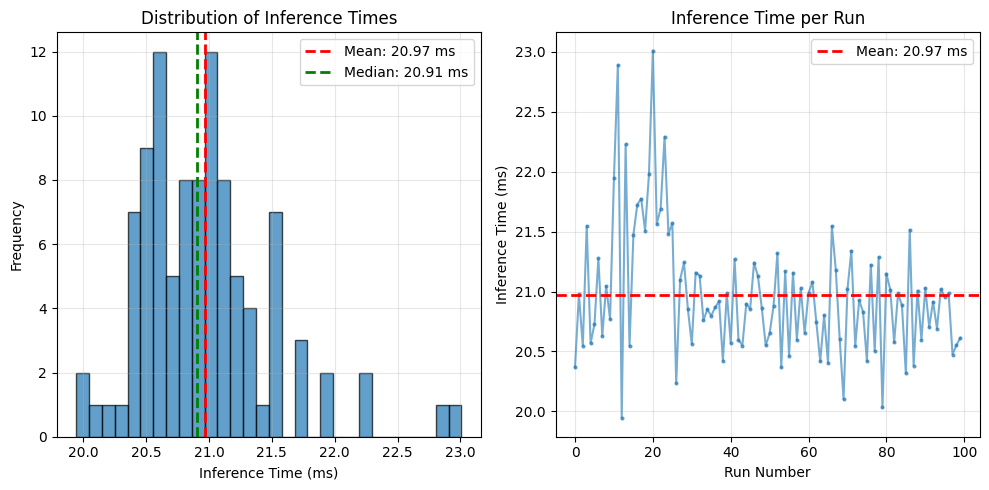


Benchmark complete!


In [13]:
import time

# Select a random image from the dataset
random_sample = df.sample(n=1).iloc[0]
image_path = dataset_root / random_sample["image"]

print(f"Benchmarking inference time on: {random_sample['image_id']}")
print(f"Image path: {image_path}")

if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path}")

# Load and preprocess the image
img_pil = Image.open(image_path).convert("RGB")
img_tensor = transform(img_pil).unsqueeze(0).to(device)

# Warmup runs (important for GPU to stabilize performance)
print("\nPerforming warmup runs...")
with torch.no_grad():
    for _ in range(10):
        _ = model(img_tensor)

# Synchronize GPU before benchmarking (if using CUDA)
if device.type == "cuda":
    torch.cuda.synchronize()

# Benchmark inference time
num_runs = 100
print(f"\nRunning {num_runs} inference iterations...")

inference_times = []
with torch.no_grad():
    for i in range(num_runs):
        # Start timing
        if device.type == "cuda":
            torch.cuda.synchronize()
        start_time = time.perf_counter()
        
        # Inference
        outputs = model(img_tensor)
        
        # End timing
        if device.type == "cuda":
            torch.cuda.synchronize()
        end_time = time.perf_counter()
        
        inference_times.append((end_time - start_time) * 1000)  # Convert to milliseconds

# Calculate statistics
mean_time = np.mean(inference_times)
std_time = np.std(inference_times)
min_time = np.min(inference_times)
max_time = np.max(inference_times)
median_time = np.median(inference_times)

# Display results
print("\n" + "=" * 60)
print(" INFERENCE TIME BENCHMARK RESULTS")
print("=" * 60)
print(f"Device:              {device}")
print(f"Number of runs:      {num_runs}")
print(f"Image size:          224 x 224")
print("-" * 60)
print(f"Mean time:           {mean_time:.2f} ms")
print(f"Median time:         {median_time:.2f} ms")
print(f"Std deviation:       {std_time:.2f} ms")
print(f"Min time:            {min_time:.2f} ms")
print(f"Max time:            {max_time:.2f} ms")
print("-" * 60)
print(f"Throughput:          {1000/mean_time:.2f} images/second")
print("=" * 60)

# Plot distribution of inference times
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(inference_times, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(mean_time, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_time:.2f} ms')
plt.axvline(median_time, color='green', linestyle='--', linewidth=2, label=f'Median: {median_time:.2f} ms')
plt.xlabel('Inference Time (ms)')
plt.ylabel('Frequency')
plt.title('Distribution of Inference Times')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(inference_times, marker='o', linestyle='-', markersize=2, alpha=0.6)
plt.axhline(mean_time, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_time:.2f} ms')
plt.xlabel('Run Number')
plt.ylabel('Inference Time (ms)')
plt.title('Inference Time per Run')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBenchmark complete!")